In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [10]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('insurance.csv')

Saving insurance.csv to insurance (3).csv


In [11]:
print("Shape:", df.shape)
print(df.head())

Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [12]:
# Convert categorical → numerical
df = pd.get_dummies(df, drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)':   Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1)
}

In [14]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = round(r2_score(y_test, y_pred), 4)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)

    results[name] = {'R2': r2, 'RMSE': rmse}

    print(f"{name}  →  R²: {r2}  |  RMSE: {rmse}")

Linear Regression  →  R²: 0.7836  |  RMSE: 5796.2847
Ridge (alpha=1)  →  R²: 0.7835  |  RMSE: 5796.9782
Lasso (alpha=0.1)  →  R²: 0.7836  |  RMSE: 5796.3211


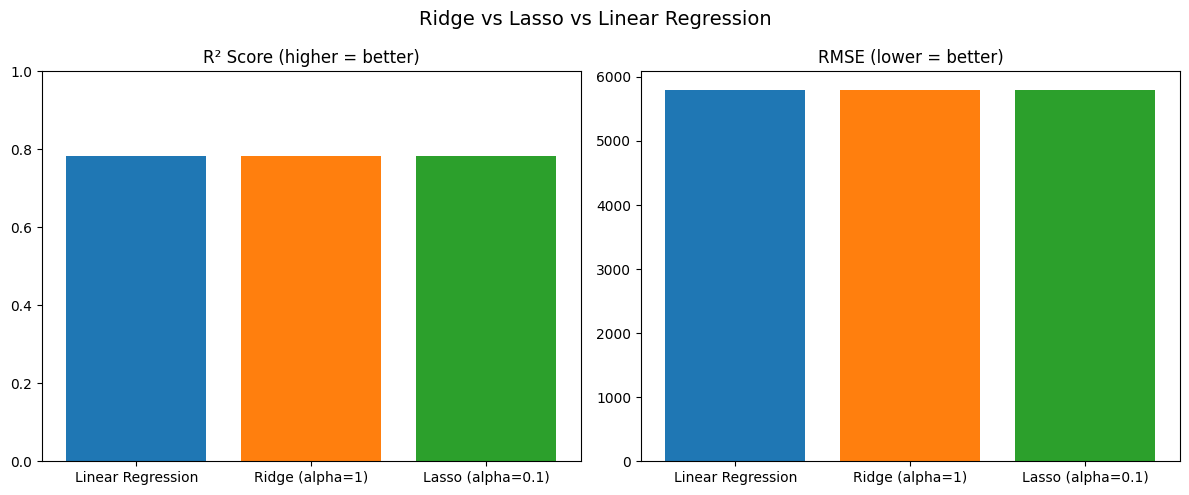

In [15]:
names  = list(results.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² Score
axes[0].bar(names, [results[m]['R2'] for m in names], color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1)

# RMSE
axes[1].bar(names, [results[m]['RMSE'] for m in names], color=colors)
axes[1].set_title('RMSE (lower = better)')

plt.suptitle('Ridge vs Lasso vs Linear Regression', fontsize=14)
plt.tight_layout()
plt.show()